In [52]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import re
warnings.filterwarnings("ignore")

linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

     Token Nums  CPU to GPU Time  GPU to CPU Time  Recomputation Time  \
171        4096         6.919698         6.843773           13.936216   
170        4081         6.949363         6.425435           12.756068   
169        4073         6.894922         6.648790           12.458070   
168        4061         6.874730         6.462006           12.966190   
167        4060         6.869707         6.643042           12.584924   
..          ...              ...              ...                 ...   
4            12         0.060224         0.051732            1.201158   
3            11         0.060960         0.051938            1.213112   
2             8         0.061226         0.052062            1.097315   
1             5         0.063176         0.052592            1.181340   
0             0         0.017599         0.011403            3.850241   

     swap_time  Difference  
171  13.763472   -0.172744  
170  13.374798    0.618730  
169  13.543712    1.085642  
168  13

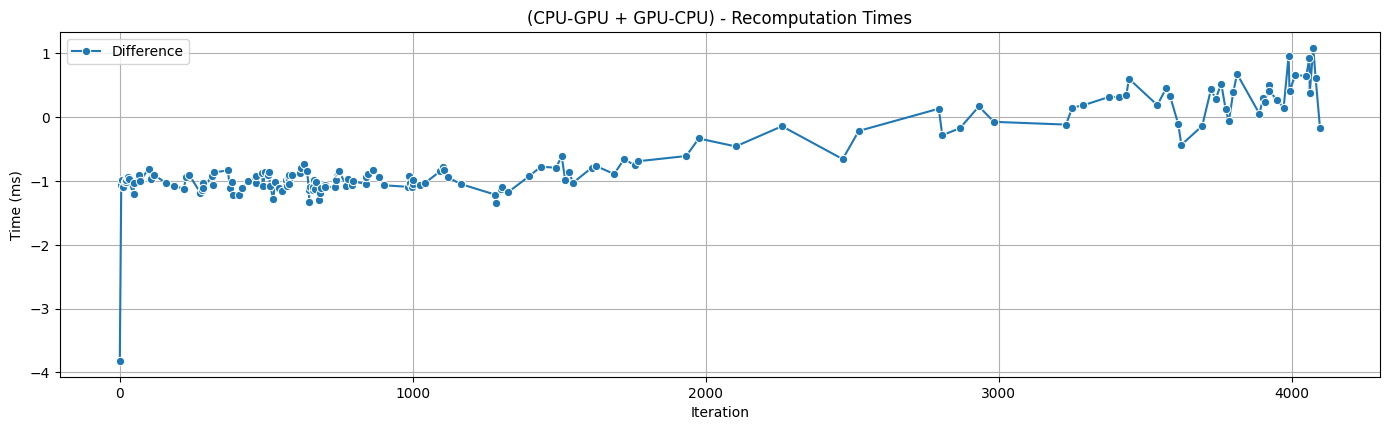

In [73]:
# 读取日志文件
with open('../server.log', 'r') as file:
    log_content = file.readlines()

# 初始化列表来存储提取的时间和token数量
cpu_to_gpu_times = []
gpu_to_cpu_times = []
recomputation_times = []
num_prefill_tokens = []
num_decode_tokens = []
token_sums = []

# 正则表达式模式
cpu_to_gpu_pattern = re.compile(r'cpu to gpu: (\d+\.\d+) ms')
gpu_to_cpu_pattern = re.compile(r'gpu to cpu: (\d+\.\d+) ms')
recomputation_pattern = re.compile(r'computation time: (\d+\.\d+) ms')
token_pattern = re.compile(r'num_blocks: (\d+), token_num: (\d+)')

# 遍历日志内容并提取时间
for line in log_content:
    cpu_to_gpu_match = cpu_to_gpu_pattern.search(line)
    gpu_to_cpu_match = gpu_to_cpu_pattern.search(line)
    recomputation_match = recomputation_pattern.search(line)
    token_match = token_pattern.search(line)
    
    if cpu_to_gpu_match:
        cpu_to_gpu_times.append(float(cpu_to_gpu_match.group(1)))
    if gpu_to_cpu_match:
        gpu_to_cpu_times.append(float(gpu_to_cpu_match.group(1)))
    if recomputation_match:
        recomputation_times.append(float(recomputation_match.group(1)))
    if token_match:
        token_sums.append(int(token_match.group(2)))

# 确保所有列表长度一致
min_length = min(len(cpu_to_gpu_times), len(gpu_to_cpu_times), len(recomputation_times), len(token_sums))
cpu_to_gpu_times = cpu_to_gpu_times[:min_length]
gpu_to_cpu_times = gpu_to_cpu_times[:min_length]
recomputation_times = recomputation_times[:min_length]
token_sums = token_sums[:min_length]

df = pd.DataFrame({
    'CPU to GPU Time': cpu_to_gpu_times,
    'GPU to CPU Time': gpu_to_cpu_times,
    'Recomputation Time': recomputation_times,
    'Token Nums': token_sums
})
df['swap_time'] = df['CPU to GPU Time'] + df['GPU to CPU Time']
df['Difference'] = (df['swap_time'] - df['Recomputation Time'])
df = df.groupby("Token Nums").mean().reset_index()
df.sort_values(by='Token Nums',ascending=False,inplace=True)
df.to_csv("communation_recompute_cost_100.csv")
# 绘制曲线图
plt.figure(figsize=(14, 8))
print(df)
plt.subplot(2, 1, 1)
sns.lineplot(data=df, x='Token Nums', y='Difference', label='Difference', marker='o')
# plt.plot(gpu_to_cpu_times, label='GPU to CPU Time', marker='o')
# plt.plot(df['Recomputation Time'], label='Recomputation Time', marker='o')
plt.xlabel('Iteration')
plt.ylabel('Time (ms)')
plt.title('(CPU-GPU + GPU-CPU) - Recomputation Times')
plt.legend()
plt.grid(True)

# plt.subplot(2, 1, 2)
# plt.plot(token_sums, label='Sum of num_prefill_tokens and num_decode_tokens', marker='o')
# plt.xlabel('Iteration')
# plt.ylabel('Sum of Tokens')
# plt.title('Sum of num_prefill_tokens and num_decode_tokens')
# plt.legend()
# plt.grid(True)

plt.tight_layout()
plt.show()